## Implementation of a Routing in RAG

### Libraries, ChatOllama, Chroma vectorstore, LLM prompt initialization

In [1]:
from chromadb.config import Settings
from chromadb import Client
from langchain.vectorstores import Chroma
import chromadb

from langchain_ollama import ChatOllama
from langchain_community.embeddings import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from typing_extensions import List, TypedDict
from langgraph.graph import START, StateGraph

import os, re, time
from datetime import datetime

date = datetime.today().strftime('%Y-%m-%d')
proj_name = "Semantic Routing"
run_count = 1
load_previous = True # Set to True to load previous run's data

# Initialize Langsmith
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "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"
os.environ["LANGSMITH_PROJECT"] = f"[{date}] VAA - {proj_name} {run_count}"

# Initialize LLMs
REASONING = True
REASONING_CLASSIFIER = False

llm = ChatOllama(model="deepseek-r1:8b", validate_model_on_init=True, temperature=0.6, reasoning=True if REASONING else False)
classifier_llm = ChatOllama(model="deepseek-r1:8b", validate_model_on_init=True, reasoning=True if REASONING_CLASSIFIER else False)
emb = OllamaEmbeddings(model="bge-m3:567m")

/var/folders/cf/1j9rc9v11rzf5wxcjw3w_wsm0000gp/T/ipykernel_24455/3903758948.py:33: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  emb = OllamaEmbeddings(model="bge-m3:567m")


In [2]:
# Initialize retriever for queries. Get the workspace root directory
import pathlib

def get_project_root() -> pathlib.Path:
    current_file_dir = pathlib.Path(pathlib.Path.cwd()).resolve().parent
    if (current_file_dir / '.git').exists():
        return current_file_dir
    for parent in current_file_dir.parents:
        if (parent / '.git').exists():
            return parent
    return pathlib.Path.cwd() # Fallback to current working directory if .git not found

ROOT_DIR = get_project_root()

chroma_db_path = ROOT_DIR / "chroma_db"
print(f"Chroma DB path: {chroma_db_path}")

client = Client(Settings())
client = chromadb.PersistentClient(path=str(chroma_db_path))

# For programme and subject information
academic_vectorstore = Chroma(
    collection_name="academic_documents", 
    client=client, 
    embedding_function=emb
)

# For sao information
sao_vectorstore = Chroma(
    collection_name="sao_documents",
    client=client,
    embedding_function=emb
)

print(f"Programme collection count  : {academic_vectorstore._collection.count()}")
print(f"SAO collection count        : {sao_vectorstore._collection.count()}")

/var/folders/cf/1j9rc9v11rzf5wxcjw3w_wsm0000gp/T/ipykernel_7697/4287713801.py:22: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  academic_vectorstore = Chroma(


Chroma DB path: /Users/MarcussPC/Desktop/Temp/CAPSTONE/chroma_db
Programme collection count  : 3291
SAO collection count        : 1152


In [3]:
# The LLM prompt
LLM_prompt = \
    """
    You are a professional academic advisor at The Hong Kong Polytechnic University. Please adhere to the following rules:
        1. Answer in the same language as the user query, e.g., English query, English answer.
        2. Avoid saying "may", "maybe", or anything similar; be affirmative, confident, and decisive in your answers.
        3. Avoid saying "based on the provided context", or anything similar; answer directly.
        4. Say no if you cannot answer the question; do not fabricate a factually false answer.
        5. Provide relevant URLs and advice to the student if necessary.

    Now, please use the following context to answer the student's question.
    Remember to be nice and ask if there are any more enquiries.

    *Context*:
    ----------
    {context}
    ----------

    *Student's Question*:
    {question}

    Helpful Answer:
    """
prompt = PromptTemplate.from_template(LLM_prompt)

### Routing Implementation

In [4]:
ROUTING_PROMPT = \
    """
    You are an university expert at routing a student's question to a vectorstore.

    The vectorstores contain documents with information about the following topics:
    1. 'academic': 
        - Programme booklets, 
        - Subject information, 
        - General academic information,  
        - Academic requirements,
        - Study planning.
    2. 'sao': 
        - Personal growth, 
        - Holistic development, 
        - University facilities, 
        - Student services,
        - Career information from the Student Affairs Office.

    Based on the student's question, determine which vectorstore is the most relevant.
    Return a single word ONLY, either 'academic' or 'sao'.

    *Question*: 
    {question}

    Answer:
    """
    
routing_prompt = PromptTemplate.from_template(ROUTING_PROMPT)

In [5]:
# Defining the class structure for the LLM
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str
    datasource: str

# Function to classify the question
def route_question(state: State): 
    prompt = routing_prompt
    router = prompt | classifier_llm
    result = router.invoke({"question": state["question"]})
    
    print(f"Routing decision: {result.content}")
    
    if "academic" in result.content.lower():
        return "retrieve_academic"
    else:
        return "retrieve_sao"

# Retrieval functions for each vectorstore
def retrieve_academic(state: State):
    retrieved_docs = academic_vectorstore.similarity_search(str(state["question"]), k=5)

    # Debugging
    '''
    for result in retrieved_docs:
        print("========================================================")
        print(f"Content: {result.page_content}...")
        print(f"Source: {result.metadata.get('source')}")
        print(f"Chunk ID: {result.metadata.get('chunk_id')}\n")
    '''

    return {"context": retrieved_docs, "datasource": "programme"}
def retrieve_sao(state: State):
    retrieved_docs = sao_vectorstore.similarity_search(str(state["question"]), k=5)

    # Debugging
    '''
    for result in retrieved_docs:
        print("========================================================")
        print(f"Content: {result.page_content}...")
        print(f"Source: {result.metadata.get('source')}")
        print(f"Chunk ID: {result.metadata.get('chunk_id')}\n")
    '''

    return {"context": retrieved_docs, "datasource": "sao"}

# Functions for constructing the final LLM prompt
def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    #print(response.additional_kwargs)

    # Include the reasoning part in the output
    return {"answer": f"<think>\n{response.additional_kwargs.get("reasoning_content", "")}</think>\n\n{response.content}"}

    # NOT Include the reasoning part
    #return {"answer": f"{response.content}"}

# Functions for graph building (a process sequence)
def graph_building():
    global graph
    graph_builder = StateGraph(State)
    
    graph_builder.add_node("retrieve_academic", retrieve_academic)
    graph_builder.add_node("retrieve_sao", retrieve_sao)
    graph_builder.add_node("generate", generate)
    
    graph_builder.add_conditional_edges(
        START,
        route_question,
        {
            "retrieve_academic": "retrieve_academic",
            "retrieve_sao": "retrieve_sao",
        },
    )
    
    graph_builder.add_edge("retrieve_academic", "generate")
    graph_builder.add_edge("retrieve_sao", "generate")
    
    graph = graph_builder.compile()

graph_building()

### Optional: Testing

In [6]:
query = \
"How can I apply for residential hall in PolyU?"

print(f"Generating {query}")
result = graph.invoke({"question": query})

print(f"\nPlease see Langsmith for the full details of the execution trace.\n")

Generating How can I apply for residential hall in PolyU?
Routing decision: sao

Please see Langsmith for the full details of the execution trace.



# =================================
### Define Test Dataset

In [2]:
# Test dataset with questions and expected answer
test_dataset = [
    {
        "question": "What is the potential career path after studying in BEng Scheme in EE?",
        "category": "career",
        "expected_keywords": ["engineer", "industry", "hardware", "professional"],
        "ground_truth": None
    },
    {
        "question": "How can I apply for residential hall in the PolyU?",
        "category": "facility",
        "expected_keywords": ["admission", "application", "submit", "procedure"],
        "ground_truth": None
    },
    {
        "question": "What courses are offered in the first year in BEng/BSc Scheme in IAIE?",
        "category": "curriculum",
        "expected_keywords": ["course", "year", "subject", "semester"],
        "ground_truth": None
    },
    {
        "question": "I am a year 3 student studying in BSc Information Security. What should I do if I failed a subject?",
        "category": "academic",
        "expected_keywords": ["retake", "GPA", "grade", "tie-subject"],
        "ground_truth": None
    },
    {
        "question": "Are there any internship opportunities available?",
        "category": "internship",
        "expected_keywords": ["internship", "placement", "work", "experience"],
        "ground_truth": None
    },
]

### Define Evaluation Metrics

In [3]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer

class RetrievalMetrics:
    """Metrics to evaluate retrieval quality"""
    
    @staticmethod
    def safe_cosine_similarity(vec1, vec2):
        """Calculate cosine similarity with safety checks for numerical stability"""

        try:
            vec1 = np.array(vec1, dtype=np.float64)
            vec2 = np.array(vec2, dtype=np.float64)
            if np.any(np.isnan(vec1)) or np.any(np.isnan(vec2)):
                return 0.0
            if np.any(np.isinf(vec1)) or np.any(np.isinf(vec2)):
                return 0.0
            
            # Calculate norms
            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)
            
            # Check for zero-length vectors
            if norm1 == 0 or norm2 == 0:
                return 0.0
            
            # Calculate cosine similarity manually to avoid overflow
            dot_product = np.dot(vec1, vec2)
            similarity = dot_product / (norm1 * norm2)
            
            # Clip to valid range [-1, 1] to handle numerical errors
            similarity = np.clip(similarity, -1.0, 1.0)
            
            return float(similarity)
        except Exception as e:
            print(f"Error calculating cos similarity: {e}")
            return 0.0
    
    @staticmethod
    def calculate_retrieval_scores(query: str, retrieved_docs: List[Document], emb_model) -> dict:
        """Calculate various retrieval metrics with numerical stability"""

        if not retrieved_docs:
            return {
                "avg_similarity": 0, 
                "max_similarity": 0, 
                "min_similarity": 0, 
                "std_similarity": 0,
                "num_docs": 0
            }
        
        try:
            # Get query embedding & document embeddings
            query_embedding = emb_model.embed_query(query)
            doc_embeddings = [emb_model.embed_query(doc.page_content) for doc in retrieved_docs]
            
            # Calculate cosine similarities using safe method
            similarities = []
            for doc_emb in doc_embeddings:
                sim = RetrievalMetrics.safe_cosine_similarity(query_embedding, doc_emb)
                similarities.append(sim)
            
            # Filter out invalid similarities
            valid_similarities = [s for s in similarities if not np.isnan(s) and not np.isinf(s)]
            
            if not valid_similarities:
                return {
                    "avg_similarity": 0, 
                    "max_similarity": 0, 
                    "min_similarity": 0,
                    "std_similarity": 0, 
                    "num_docs": len(retrieved_docs)
                }
            
            return {
                "avg_similarity": float(np.mean(valid_similarities)),
                "max_similarity": float(np.max(valid_similarities)),
                "min_similarity": float(np.min(valid_similarities)),
                "std_similarity": float(np.std(valid_similarities)),
                "num_docs": len(retrieved_docs)
            }
        except Exception as e:
            print(f"Warning: Error in calculate_retrieval_scores: {e}")
            return {
                "avg_similarity": 0, 
                "max_similarity": 0, 
                "min_similarity": 0,
                "std_similarity": 0,
                "num_docs": len(retrieved_docs)
            }
    
    @staticmethod
    def calculate_diversity(retrieved_docs: List[Document]) -> float:
        """Calculate diversity of retrieved documents with numerical stability"""

        if len(retrieved_docs) < 2:
            return 0.0
        
        try:
            # Calculate pairwise similarity between documents
            doc_texts = [doc.page_content for doc in retrieved_docs]
            doc_embeddings = [emb.embed_query(text) for text in doc_texts]
            
            similarities = []
            for i in range(len(doc_embeddings)):
                for j in range(i + 1, len(doc_embeddings)):
                    sim = RetrievalMetrics.safe_cosine_similarity(doc_embeddings[i], doc_embeddings[j])
                    if not np.isnan(sim) and not np.isinf(sim):
                        similarities.append(sim)
            
            # Diversity is 1 - average similarity
            if not similarities:
                return 0.0
                
            return float(1 - np.mean(similarities))
        except Exception as e:
            print(f"Warning: Error calculating diversity: {e}")
            return 0.0

print("Retrieval metrics implemented")

class AnswerQualityMetrics:
    """Metrics to evaluate answer quality"""
    
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    def check_keyword_coverage(self, answer: str, expected_keywords: List[str]) -> float:
        """Check how many expected keywords appear in the answer"""

        if not expected_keywords:
            return 1.0
        
        answer_lower = answer.lower()
        found = sum(1 for keyword in expected_keywords if keyword.lower() in answer_lower)
        return found / len(expected_keywords)
    
    def calculate_rouge_scores(self, answer: str, reference: str) -> dict:
        """Calculate ROUGE scores if reference answer is available"""

        if not reference:
            return {"rouge1": None, "rouge2": None, "rougeL": None}
        
        scores = self.rouge_scorer.score(reference, answer)
        return {
            "rouge1": scores['rouge1'].fmeasure,
            "rouge2": scores['rouge2'].fmeasure,
            "rougeL": scores['rougeL'].fmeasure
        }

answer_metrics = AnswerQualityMetrics()
print("Answer quality metrics implemented")

class AdditionalMetrics:
    """Additional evaluation metrics"""
    
    @staticmethod
    def calculate_answer_length(answer: str) -> dict:
        """Calculate answer length statistics"""

        words = answer.split()
        return {
            "word_count": len(words),
            "char_count": len(answer),
            "sentence_count": len(re.split(r'[.!?]+', answer))
        }
    
    @staticmethod
    def detect_hallucination_indicators(answer: str) -> dict:
        """Detect potential hallucination indicators"""

        uncertainty_words = ['may', 'maybe', 'possibly', 'perhaps', 'might', 'could']
        hedging_phrases = ['based on', 'according to', 'it seems', 'it appears']
        answer_lower = answer.lower()
        
        return {
            "has_uncertainty": any(word in answer_lower for word in uncertainty_words),
            "has_hedging": any(phrase in answer_lower for phrase in hedging_phrases),
            "uncertainty_count": sum(1 for word in uncertainty_words if word in answer_lower)
        }
    
    @staticmethod
    def calculate_context_utilization(answer: str, context_docs: List[Document]) -> float:
        """Estimate how much of the context was used in the answer"""
        
        if not context_docs:
            return 0.0
        
        context_text = " ".join([doc.page_content for doc in context_docs])
        context_words = set(context_text.lower().split())
        answer_words = set(answer.lower().split())
        
        # Remove common stop words
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'are', 'was', 'were', 'be'}
        context_words -= stop_words
        answer_words -= stop_words
        
        if not context_words:
            return 0.0
        
        overlap = len(answer_words.intersection(context_words))
        return overlap / len(context_words) if context_words else 0.0

additional_metrics = AdditionalMetrics()
print("Additional metrics implemented")

Retrieval metrics implemented
Answer quality metrics implemented
Additional metrics implemented


### Evaluation Process

In [4]:
def evaluate_single_query(test_item: dict, graph, emb_model, answer_metrics) -> dict:
    """Evaluate a single query comprehensively. This function extracts all metrics including retrieval quality, answer quality, and hallucination status."""

    question = test_item["question"]
    
    print(f"\nEvaluating: {question}")
    
    # Run RAG system
    result = graph.invoke({"question": question})
    answer = result["answer"]
    retrieved_docs = result.get("context")  # MAKE SURE: State the correct dict key
    
    # Calculate all metrics
    evaluation = {
        "question": question,
        "category": test_item["category"],
        "answer": answer,
    }

    print(f"Retrieved {len(retrieved_docs)} documents")
    
    # Retrieval metrics
    retrieval_scores = RetrievalMetrics.calculate_retrieval_scores(question, retrieved_docs, emb_model)
    evaluation.update({f"retrieval_{k}": v for k, v in retrieval_scores.items()})
    evaluation["retrieval_diversity"] = RetrievalMetrics.calculate_diversity(retrieved_docs)
    
    # Answer quality metrics
    evaluation["keyword_coverage"] = answer_metrics.check_keyword_coverage(answer, test_item["expected_keywords"])
    
    # Additional metrics
    length_stats = additional_metrics.calculate_answer_length(answer)
    evaluation.update({f"length_{k}": v for k, v in length_stats.items()})
    
    hallucination_indicators = additional_metrics.detect_hallucination_indicators(answer)
    evaluation.update({f"hallucination_{k}": v for k, v in hallucination_indicators.items()})
    
    evaluation["context_utilization"] = additional_metrics.calculate_context_utilization(answer, retrieved_docs)
    
    # ROUGE scores (only if ground truth is available)
    if test_item.get("ground_truth"):
        rouge_scores = answer_metrics.calculate_rouge_scores(answer, test_item["ground_truth"])
        evaluation.update({f"rouge_{k}": v for k, v in rouge_scores.items()})

    print(f"Retrieval Min Similarity: {evaluation.get('retrieval_min_similarity'):.3f}")
    print(f"Retrieval Avg Similarity: {evaluation.get('retrieval_avg_similarity'):.3f}")
    print(f"Retrieval Max Similarity: {evaluation.get('retrieval_max_similarity'):.3f}")
    print(f"Retrieval Diversity: {evaluation['retrieval_diversity']:.3f}")
    print(f"Keyword Coverage: {evaluation['keyword_coverage']:.3f}")
    print(f"Context Utilization: {evaluation.get('context_utilization'):.3f}")
    print(f"Halluncination Uncertainties: {evaluation.get('hallucination_has_uncertainty'):.3f}")
    
    return evaluation


In [10]:
# Run evaluation on all test data
print("STARTING COMPREHENSIVE RAG EVALUATION")

results = []
for test_item in test_dataset:
    eval_result = evaluate_single_query(test_item, graph, emb, answer_metrics)
    results.append(eval_result)

print(f"\n{len(results)} queries evaluated")

STARTING COMPREHENSIVE RAG EVALUATION

Evaluating: What is the potential career path after studying in BEng Scheme in EE?
Routing decision: academic
Retrieved 5 documents
Retrieval Min Similarity: 0.649
Retrieval Avg Similarity: 0.654
Retrieval Max Similarity: 0.662
Retrieval Diversity: 0.119
Keyword Coverage: 0.500
Context Utilization: 0.259
Halluncination Uncertainties: 1.000

Evaluating: How can I apply for residential hall in the PolyU?
Routing decision: sao
Retrieved 5 documents
Retrieval Min Similarity: 0.702
Retrieval Avg Similarity: 0.713
Retrieval Max Similarity: 0.735
Retrieval Diversity: 0.140
Keyword Coverage: 0.750
Context Utilization: 0.282
Halluncination Uncertainties: 1.000

Evaluating: What courses are offered in the first year in BEng/BSc Scheme in IAIE?
Routing decision: academic
Retrieved 5 documents
Retrieval Min Similarity: 0.701
Retrieval Avg Similarity: 0.705
Retrieval Max Similarity: 0.712
Retrieval Diversity: 0.067
Keyword Coverage: 0.750
Context Utilization: 

### Results Analysis and Visualization

In [5]:
metric_columns = [
    'keyword_coverage', 'retrieval_avg_similarity', 'retrieval_max_similarity', 
    'retrieval_min_similarity', 'retrieval_diversity', 'context_utilization',
    'length_word_count', 'hallucination_uncertainty_count'
]

In [6]:
# Function to load previous results (if needed)

def load_previous_results(filepath: str = 'Evaluation/rag_evaluation_results.csv') -> pd.DataFrame:
    """Load previously saved evaluation results from CSV file"""
    try:
        df_loaded = pd.read_csv(filepath)
        print(f"Successfully loaded {len(df_loaded)} results from {filepath}")
        return df_loaded
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

In [7]:
# Convert results to DataFrame
df_results = load_previous_results() if load_previous else pd.DataFrame(results) 

# Display summary statistics
print("EVALUATION SUMMARY STATISTICS\n")

summary_stats = df_results[metric_columns].describe()
print(summary_stats.round(3))

# Save results
if load_previous:
    print("\nPrevious results loaded; skipping save.")
else:
    df_results.to_csv('Evaluation/rag_evaluation_results.csv', index=False) 
    print("\nResults saved")

Successfully loaded 5 results from Evaluation/rag_evaluation_results.csv
EVALUATION SUMMARY STATISTICS

       keyword_coverage  retrieval_avg_similarity  retrieval_max_similarity  \
count             5.000                     5.000                     5.000   
mean              0.650                     0.672                     0.689   
std               0.137                     0.034                     0.035   
min               0.500                     0.644                     0.652   
25%               0.500                     0.645                     0.662   
50%               0.750                     0.654                     0.685   
75%               0.750                     0.705                     0.712   
max               0.750                     0.713                     0.735   

       retrieval_min_similarity  retrieval_diversity  context_utilization  \
count                     5.000                5.000                5.000   
mean                      0.66

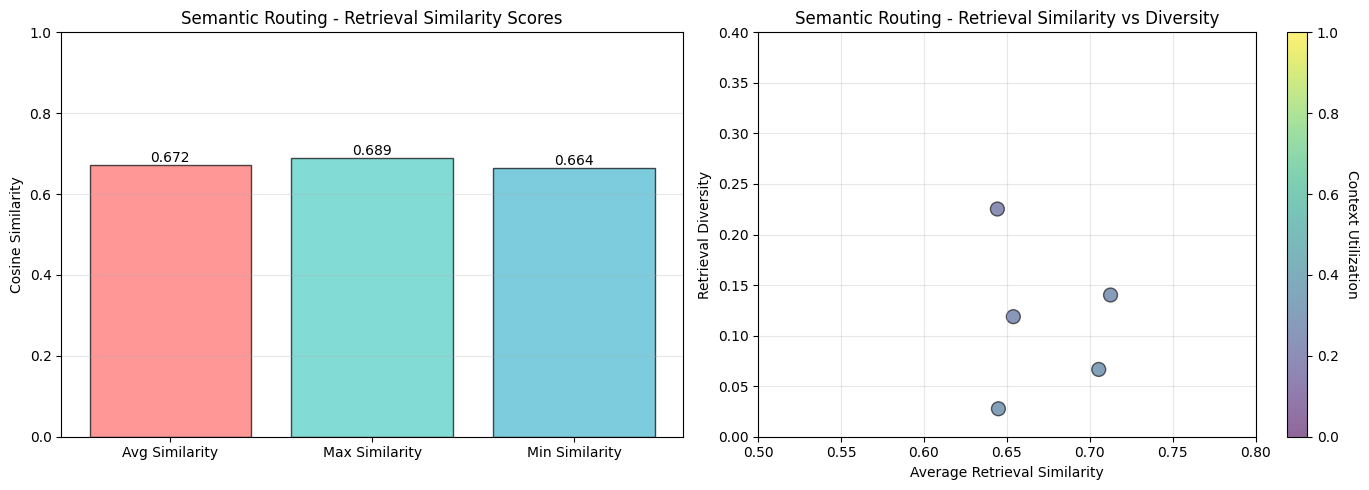

Retrieval analysis chart saved


In [8]:
# Retrieval Quality Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retrieval similarity distribution
ax1 = axes[0]
retrieval_metrics = ['retrieval_avg_similarity', 'retrieval_max_similarity', 'retrieval_min_similarity']
retrieval_data = df_results[retrieval_metrics].mean()

bars1 = ax1.bar(range(len(retrieval_data)), retrieval_data.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(retrieval_data)))
ax1.set_xticklabels(['Avg Similarity', 'Max Similarity', 'Min Similarity'])
ax1.set_ylabel('Cosine Similarity')
ax1.set_title(f'{proj_name} - Retrieval Similarity Scores')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')

# Diversity vs Similarity scatter
ax2 = axes[1]
scatter = ax2.scatter(df_results['retrieval_avg_similarity'], df_results['retrieval_diversity'], c=df_results['context_utilization'], cmap='viridis', s=100, alpha=0.6, edgecolor='black')
ax2.set_xlabel('Average Retrieval Similarity')
ax2.set_ylabel('Retrieval Diversity')
ax2.set_title(f'{proj_name} - Retrieval Similarity vs Diversity')
ax2.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Context Utilization', rotation=270, labelpad=15)
# set context utilization color bar range from 0 to 1
cbar.mappable.set_clim(0, 1)
# set retrieval avg similarity x axis from 0 to 1 and retrieval diversity y axis from 0 to 1
ax2.set_xlim(0.5, 0.8)
ax2.set_ylim(0, 0.4)

plt.tight_layout()
plt.savefig('Evaluation/rag_retrieval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Retrieval analysis chart saved")

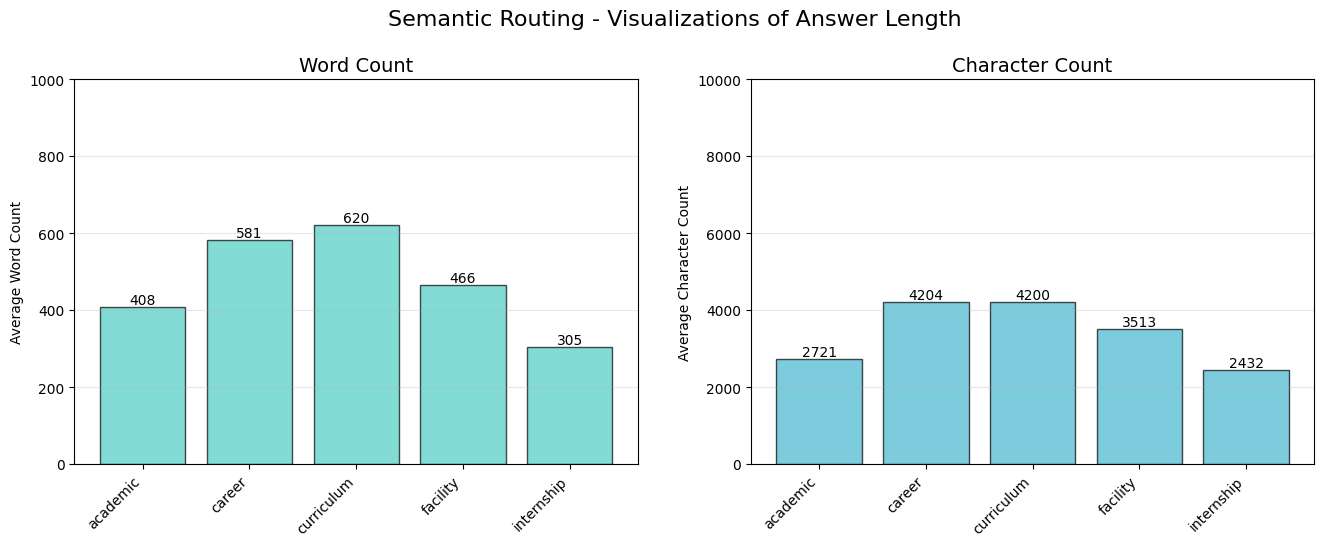

Answer length analysis chart saved


In [9]:
# Answer Length Analysis by Category
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{proj_name} - Visualizations of Answer Length', fontsize=16, y=1.02)

categories = sorted(df_results['category'].unique())

# Word count by category
ax1 = axes[0]
category_word_count = df_results.groupby('category')['length_word_count'].mean().sort_index()
bars1 = ax1.bar(range(len(category_word_count)), category_word_count.values, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(category_word_count)))
ax1.set_xticklabels(category_word_count.index, rotation=45, ha='right')
ax1.set_ylabel('Average Word Count')
ax1.set_title('Word Count', fontsize=14)
ax1.set_ylim(0, 1000)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha='center', va='bottom', fontsize=10)

# Character count by category
ax2 = axes[1]
category_char_count = df_results.groupby('category')['length_char_count'].mean().sort_index()
bars2 = ax2.bar(range(len(category_char_count)), category_char_count.values, color='#45B7D1', alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(category_char_count)))
ax2.set_xticklabels(category_char_count.index, rotation=45, ha='right')
ax2.set_ylabel('Average Character Count')
ax2.set_title('Character Count', fontsize=14)
ax2.set_ylim(0, 10000)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha='center', va='bottom', fontsize=10)

plt.savefig('Evaluation/rag_answer_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Answer length analysis chart saved")

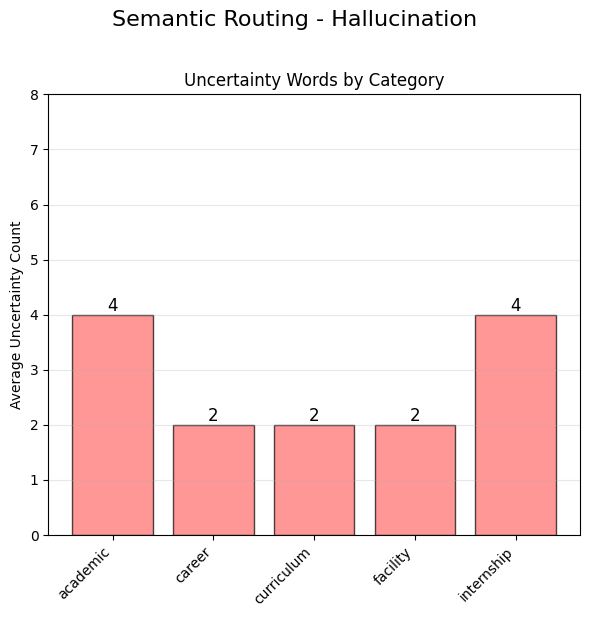

Hallucination indicators chart saved


In [10]:
# Hallucination Indicators Analysis
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
fig.suptitle(f'{proj_name} - Hallucination', fontsize=16, y=1.02)

# Average uncertainty count by category
ax1 = axes
categories = sorted(df_results['category'].unique())
category_uncertainty = df_results.groupby('category')['hallucination_uncertainty_count'].mean().sort_index()
bars1 = ax1.bar(range(len(category_uncertainty)), category_uncertainty.values, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(category_uncertainty)))
ax1.set_xticklabels(category_uncertainty.index, rotation=45, ha='right')
ax1.set_ylabel('Average Uncertainty Count')
ax1.set_title('Uncertainty Words by Category')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 8)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('Evaluation/rag_hallucination_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Hallucination indicators chart saved")

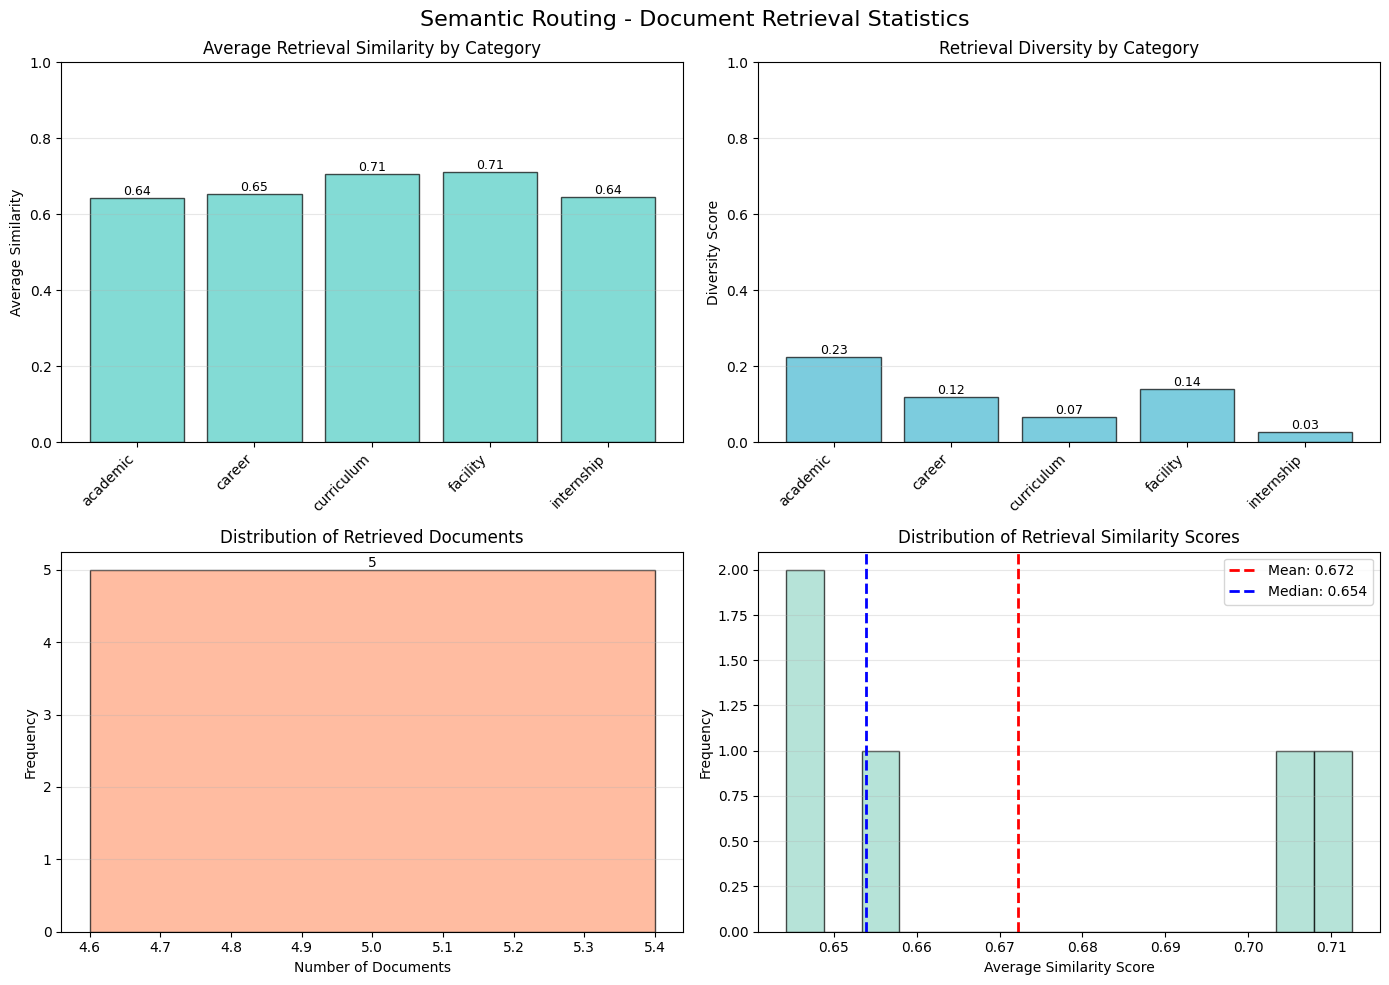

Retrieval statistics chart saved


In [11]:
# Document Retrieval Statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{proj_name} - Document Retrieval Statistics', fontsize=16)

# Retrieval similarity by category
ax1 = axes[0, 0]
category_retrieval = df_results.groupby('category')['retrieval_avg_similarity'].mean().sort_index()
bars1 = ax1.bar(range(len(category_retrieval)), category_retrieval.values, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(category_retrieval)))
ax1.set_xticklabels(category_retrieval.index, rotation=45, ha='right')
ax1.set_ylabel('Average Similarity')
ax1.set_title('Average Retrieval Similarity by Category')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Retrieval diversity by category
ax2 = axes[0, 1]
category_diversity = df_results.groupby('category')['retrieval_diversity'].mean().sort_index()
bars2 = ax2.bar(range(len(category_diversity)), category_diversity.values, color='#45B7D1', alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(category_diversity)))
ax2.set_xticklabels(category_diversity.index, rotation=45, ha='right')
ax2.set_ylabel('Diversity Score')
ax2.set_title('Retrieval Diversity by Category')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Number of documents retrieved
ax3 = axes[1, 0]
num_docs = df_results['retrieval_num_docs'].value_counts().sort_index()
bars3 = ax3.bar(num_docs.index, num_docs.values, color='#FFA07A', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Number of Documents')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Retrieved Documents')
ax3.grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')

# Retrieval similarity distribution
ax4 = axes[1, 1]
ax4.hist(df_results['retrieval_avg_similarity'], bins=15, color='#98D8C8', alpha=0.7, edgecolor='black')
ax4.axvline(df_results['retrieval_avg_similarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_results["retrieval_avg_similarity"].mean():.3f}')
ax4.axvline(df_results['retrieval_avg_similarity'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df_results["retrieval_avg_similarity"].median():.3f}')
ax4.set_xlabel('Average Similarity Score')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Retrieval Similarity Scores')
ax4.grid(axis='y', alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('Evaluation/rag_retrieval_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Retrieval statistics chart saved")

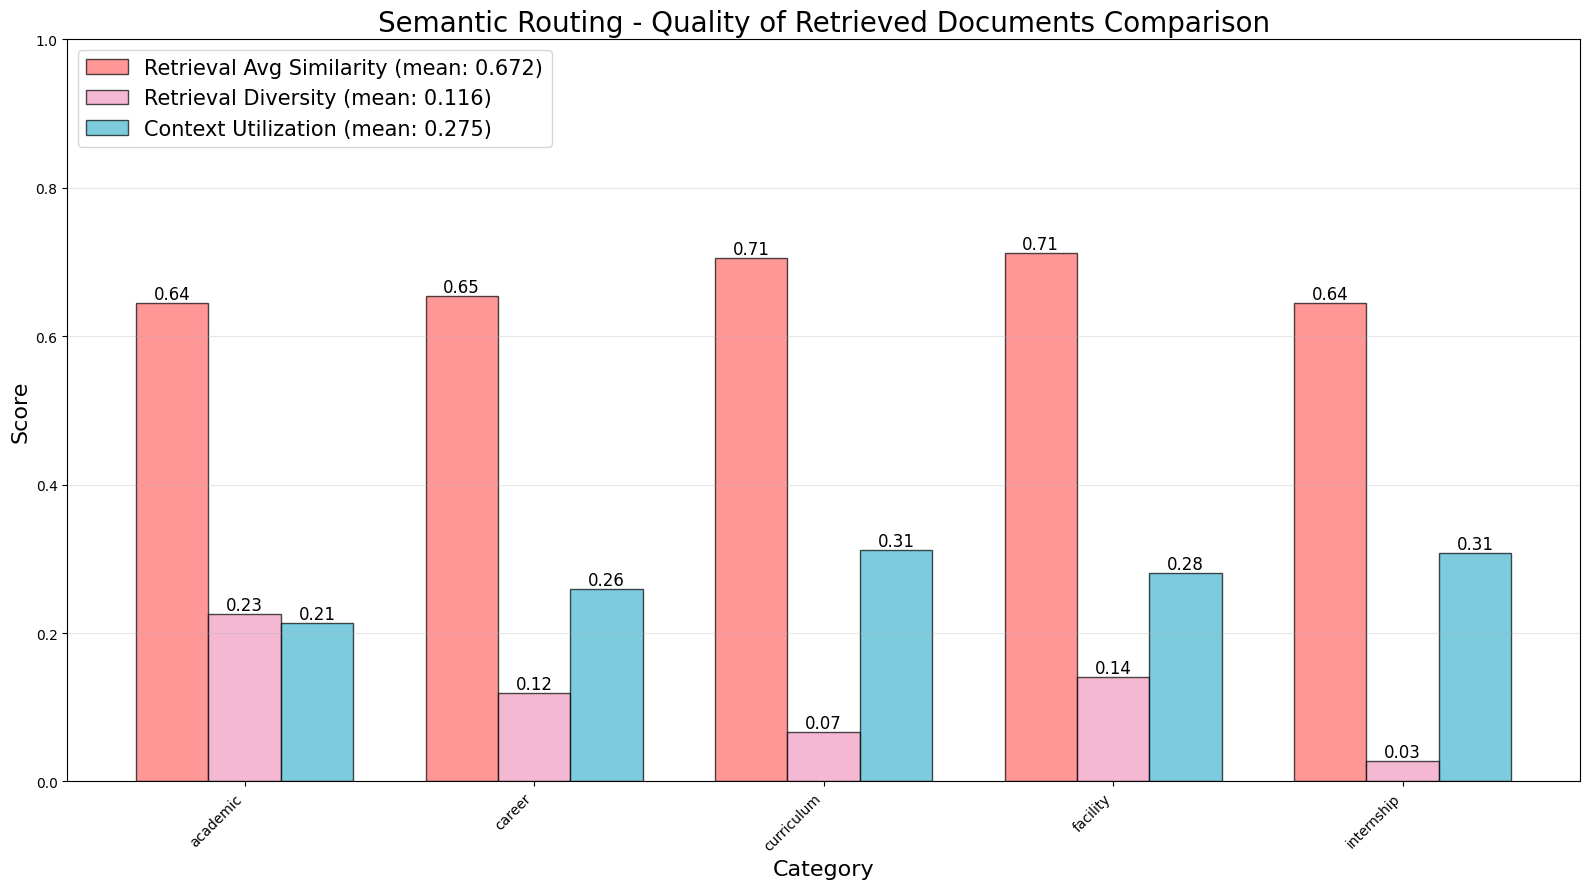

Multi-metric comparison chart saved


In [12]:
# Multi-metric Comparison Across Categories
fig, ax = plt.subplots(figsize=(16, 9))

categories = sorted(df_results['category'].unique())
metrics_compare = ['retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization']
x = np.arange(len(categories))
width = 0.25

colors_multi = ['#FF6B6B', "#F19BBF", '#45B7D1']

for idx, metric in enumerate(metrics_compare):
    values = [df_results[df_results['category'] == cat][metric].mean() for cat in categories]
    offset = (idx - len(metrics_compare)/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=metric.replace('_', ' ').title(), color=colors_multi[idx], alpha=0.7, edgecolor='black')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=12, rotation=0)

# Add mean value for each metric to the legend
legend_labels = []
for idx, metric in enumerate(metrics_compare):
    mean_value = df_results[metric].mean()
    legend_labels.append(f'{metric.replace("_", " ").title()} (mean: {mean_value:.3f})')

ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Score', fontsize=16)
ax.set_title(f'{proj_name} - Quality of Retrieved Documents Comparison', fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(legend_labels, loc='upper left', fontsize=15)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Evaluation/rag_multi_metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Multi-metric comparison chart saved")

### DETAILED Report

In [13]:
# Generate detailed report
print(f"{proj_name} - DETAILED EVALUATION REPORT\n")

# Overall performance
print("\nOVERALL PERFORMANCE (mean:standard-deviation):")
for metric in metric_columns:
    mean_val = df_results[metric].mean()
    std_val = df_results[metric].std()
    print(f"{metric} --- {mean_val:.3f} ± {std_val:.3f}")

# Best and worst performing queries
print("\nBEST PERFORMING QUERY (by keyword coverage):")
best_idx = df_results['keyword_coverage'].idxmax()
print(f"Question: {df_results.loc[best_idx, 'question']}")
print(f"Keyword Coverage: {df_results.loc[best_idx, 'keyword_coverage']:.3f}")
print(f"Retrieval Avg Similarity: {df_results.loc[best_idx, 'retrieval_avg_similarity']:.3f}")
print(f"Context Utilization: {df_results.loc[best_idx, 'context_utilization']:.3f}")

print("\nWEAKEST PERFORMING QUERY (by keyword coverage):")
worst_idx = df_results['keyword_coverage'].idxmin()
print(f"Question: {df_results.loc[worst_idx, 'question']}")
print(f"Keyword Coverage: {df_results.loc[worst_idx, 'keyword_coverage']:.3f}")
print(f"Retrieval Avg Similarity: {df_results.loc[worst_idx, 'retrieval_avg_similarity']:.3f}")
print(f"Context Utilization: {df_results.loc[worst_idx, 'context_utilization']:.3f}")

# Category analysis
print("\nPERFORMANCE BY CATEGORY:")
for category in df_results['category'].unique():
    cat_data = df_results[df_results['category'] == category]
    print(f"\n{category.upper()}:")
    print(f"  Keyword Coverage: {cat_data['keyword_coverage'].mean():.3f}")
    print(f"  Retrieval Avg Similarity: {cat_data['retrieval_avg_similarity'].mean():.3f}")
    print(f"  Context Utilization: {cat_data['context_utilization'].mean():.3f}")

# Hallucination analysis
print("\nHALLUCINATION?")
print(f"Queries with uncertainty words: {df_results['hallucination_has_uncertainty'].sum()}/{len(df_results)}")
print(f"Queries with hedging phrases: {df_results['hallucination_has_hedging'].sum()}/{len(df_results)}")
print(f"Average uncertainty count: {df_results['hallucination_uncertainty_count'].mean():.2f}")

print("\n\nEVALUATION COMPLETE")

Semantic Routing - DETAILED EVALUATION REPORT


OVERALL PERFORMANCE (mean:standard-deviation):
keyword_coverage --- 0.650 ± 0.137
retrieval_avg_similarity --- 0.672 ± 0.034
retrieval_max_similarity --- 0.689 ± 0.035
retrieval_min_similarity --- 0.664 ± 0.035
retrieval_diversity --- 0.116 ± 0.075
context_utilization --- 0.275 ± 0.040
length_word_count --- 476.000 ± 128.185
hallucination_uncertainty_count --- 2.800 ± 1.095

BEST PERFORMING QUERY (by keyword coverage):
Question: How can I apply for residential hall in the PolyU?
Keyword Coverage: 0.750
Retrieval Avg Similarity: 0.713
Context Utilization: 0.282

WEAKEST PERFORMING QUERY (by keyword coverage):
Question: What is the potential career path after studying in BEng Scheme in EE?
Keyword Coverage: 0.500
Retrieval Avg Similarity: 0.654
Context Utilization: 0.259

PERFORMANCE BY CATEGORY:

CAREER:
  Keyword Coverage: 0.500
  Retrieval Avg Similarity: 0.654
  Context Utilization: 0.259

FACILITY:
  Keyword Coverage: 0.750
  Retrieval

### Addition

In [14]:
# Create comprehensive JSON report
report = {
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_info": {
        "total_queries": len(test_dataset),
        "categories": list(df_results['category'].unique())
    },
    "overall_metrics": {
        metric: {
            "mean": float(df_results[metric].mean()),
            "std": float(df_results[metric].std()),
            "min": float(df_results[metric].min()),
            "max": float(df_results[metric].max())
        }
        for metric in metric_columns
    },
    "category_performance": {
        category: {
            metric: float(df_results[df_results['category'] == category][metric].mean()) for metric in ['keyword_coverage', 'retrieval_avg_similarity', 'retrieval_diversity', 'context_utilization']
        }
        for category in df_results['category'].unique()
    },
}

with open('Evaluation/rag_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("Full evaluation report saved")

Full evaluation report saved
